In [18]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb


In [2]:
data = pd.read_csv('test.csv')
data

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score
0,fffe31003300390039003000,2008-12-10,Female,Service,No,2.0,5.0,7.7
1,fffe31003300310037003800,2008-08-14,Female,Product,Yes,1.0,2.0,5.2
2,fffe33003400380035003900,2008-11-13,Male,Product,Yes,1.0,3.0,5.9
3,fffe3100370039003200,2008-02-07,Female,Service,No,3.0,6.0,4.6
4,fffe32003600390036003700,2008-07-17,Female,Product,No,2.0,5.0,6.4
...,...,...,...,...,...,...,...,...
12245,fffe3900310034003700,2008-10-02,Female,Service,Yes,1.0,2.0,6.1
12246,fffe32003600330034003000,2008-03-31,Female,Product,Yes,2.0,4.0,5.9
12247,fffe31003800340039003000,2008-02-12,Male,Service,No,4.0,7.0,9.6
12248,fffe32003600380031003800,2008-02-06,Male,Service,No,3.0,6.0,6.7


In [3]:
df = pd.read_csv('train.csv')
df

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52
...,...,...,...,...,...,...,...,...,...
22745,fffe31003500370039003100,2008-12-30,Female,Service,No,1.0,3.0,NaN,0.41
22746,fffe33003000350031003800,2008-01-19,Female,Product,Yes,3.0,6.0,6.7,0.59
22747,fffe390032003000,2008-11-05,Male,Service,Yes,3.0,7.0,NaN,0.72
22748,fffe33003300320036003900,2008-01-10,Female,Service,No,2.0,5.0,5.9,0.52


# Data Cleaning and Exploratory Data Analysis

In [4]:
df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

1) We Don't impute Burn Rate

- It is your target variable
- Filling it = introducing fake labels
- Will ruin your model

In [5]:
df = df.dropna(subset=['Burn Rate'])

2) Mental Fatigue Score (2117 missing)
- We'll do median imputation to make Best feature → deserves best treatment

In [6]:
df['Mental Fatigue Score'] = df.groupby('Designation')['Mental Fatigue Score'].transform(
    lambda x: x.fillna(x.median())
)

/var/folders/g8/qhp6c0bj7r5bff1w0_ntdvrm0000gn/T/ipykernel_64936/3568092958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mental Fatigue Score'] = df.groupby('Designation')['Mental Fatigue Score'].transform(


3. Resource Allocation (1381 missing)

In [7]:
df['Resource Allocation'] = df.groupby('Designation')['Resource Allocation'].transform(
    lambda x: x.fillna(x.median())
)

/var/folders/g8/qhp6c0bj7r5bff1w0_ntdvrm0000gn/T/ipykernel_64936/1478959890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Resource Allocation'] = df.groupby('Designation')['Resource Allocation'].transform(


In [8]:
df.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

In [9]:
df1 = pd.read_csv('sample_submission.csv')
df1 

,Employee ID,Burn Rate
0,fffe32003000360033003200,0.16
1,fffe3700360033003500,0.36
2,fffe31003300320037003900,0.49
3,fffe32003400380032003900,0.20
4,fffe31003900340031003600,0.52


In [10]:
# Convert date and create tenure
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])
df['Tenure'] = (df['Date of Joining'].max() - df['Date of Joining']).dt.days

/var/folders/g8/qhp6c0bj7r5bff1w0_ntdvrm0000gn/T/ipykernel_64936/4180473543.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])
/var/folders/g8/qhp6c0bj7r5bff1w0_ntdvrm0000gn/T/ipykernel_64936/4180473543.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tenure'] = (df['Date of Joining'].max() - df['Date of Joining']).dt.days


## **EDA Report**

The EDA reveals strong and interpretable relationships between key features and employee burnout. In particular, mental fatigue, workload (resource allocation), and designation level emerge as critical factors influencing burn rate. These findings justify the use of machine learning models capable of capturing nonlinear relationships and interactions between features, and they provide a strong foundation for building predictive models in the next stage of the project.

# Baseline Model

### Linear Regression

Same features as present in dataset

In [11]:

# -------------------------
# 1. Select ORIGINAL features only
# -------------------------
features = [
    'Gender',
    'Company Type',
    'WFH Setup Available',
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score'
]

X = df[features]
y = df['Burn Rate']

# -------------------------
# 2. Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 3. Preprocessing
# -------------------------
categorical_cols = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_cols = ['Designation', 'Resource Allocation', 'Mental Fatigue Score']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

# -------------------------
# 4. Apply preprocessing
# -------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# -------------------------
# 5. Train Linear Regression
# -------------------------
model = LinearRegression()
model.fit(X_train_processed, y_train)

# -------------------------
# 6. Predictions
# -------------------------
y_pred = model.predict(X_test_processed)

# -------------------------
# 7. Evaluation
# -------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Linear Regression Results:
RMSE: 0.0632
MAE:  0.0496
R²:   0.8951


### Random Forest

In [12]:

# -------------------------
# 1. Train Random Forest
# -------------------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

# -------------------------
# 2. Predictions
# -------------------------
y_pred_rf = rf_model.predict(X_test_processed)

# -------------------------
# 3. Evaluation
# -------------------------
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE:  {mae_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Results:
RMSE: 0.0631
MAE:  0.0492
R²:   0.8953


### Feature Importance:

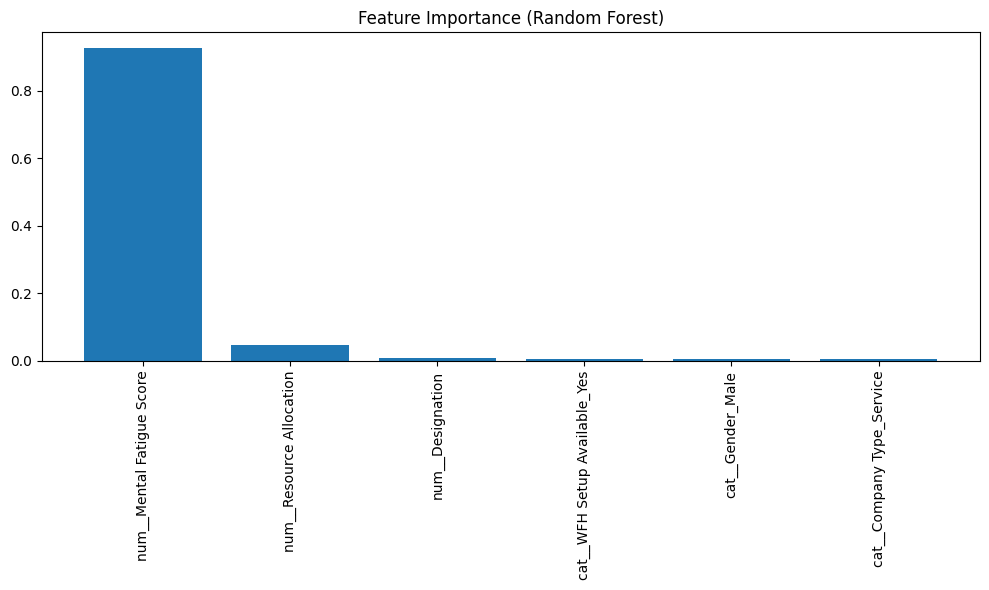

In [13]:

feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

# Sort
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [14]:

fig = px.scatter(
    x=y_test,
    y=y_pred_rf,
    labels={'x': 'Actual', 'y': 'Predicted'},
    title='Random Forest: Actual vs Predicted'
)

fig.add_shape(
    type='line',
    x0=0, y0=0,
    x1=1, y1=1,
    line=dict(color='red')
)

fig.show()

If points lie on diagonal → model is very accurate

## **Light GBM**

In [15]:
# -------------------------
# 1. Initialize model
# -------------------------
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

# -------------------------
# 2. Train
# -------------------------
lgb_model.fit(X_train_processed, y_train)

# -------------------------
# 3. Predict
# -------------------------
y_pred_lgb = lgb_model.predict(X_test_processed)

# -------------------------
# 4. Evaluate
# -------------------------
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print("LightGBM Results:")
print(f"RMSE: {rmse_lgb:.4f}")
print(f"MAE:  {mae_lgb:.4f}")
print(f"R²:   {r2_lgb:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 124
[LightGBM] [Info] Number of data points in the train set: 17300, number of used features: 6
[LightGBM] [Info] Start training from score 0.452090
LightGBM Results:
RMSE: 0.0589
MAE:  0.0463
R²:   0.9089


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



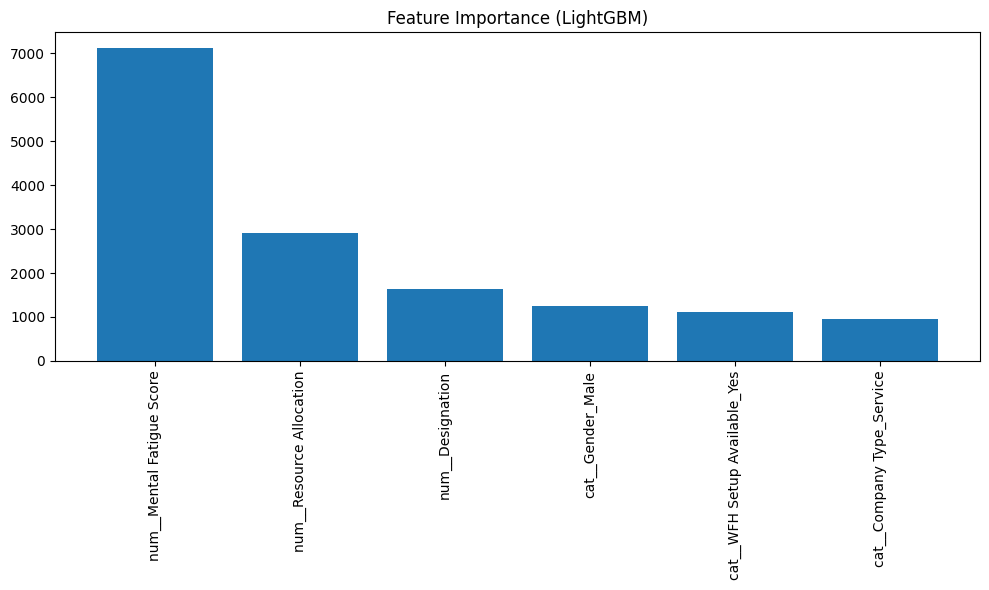

In [16]:
feature_names = preprocessor.get_feature_names_out()

importances = lgb_model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (LightGBM)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show() 

In [19]:
# Load data
df = pd.read_csv("train.csv")

# Drop missing target
df = df.dropna(subset=["Burn Rate"])

# Handle missing feature values
df["Resource Allocation"] = df["Resource Allocation"].fillna(df["Resource Allocation"].median())
df["Mental Fatigue Score"] = df["Mental Fatigue Score"].fillna(df["Mental Fatigue Score"].median())

# Original features
features = [
    "Gender",
    "Company Type",
    "WFH Setup Available",
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score"
]

X = df[features]
y = df["Burn Rate"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
categorical_cols = ["Gender", "Company Type", "WFH Setup Available"]
numerical_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Gradient Boosting model pipeline
gb_model = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(f"RMSE: {rmse_gb:.4f}")
print(f"MAE:  {mae_gb:.4f}")
print(f"R²:   {r2_gb:.4f}")

Gradient Boosting Results:
RMSE: 0.0605
MAE:  0.0476
R²:   0.9039
